In [2]:
import pandas as pd

# Load the dataset using the full path
file_path = r"C:\Users\sathi\Downloads\loan_approval_dataset.csv"
df = pd.read_csv(file_path)

# Display the first 5 rows
print("🔹 First 5 rows of the dataset:")
display(df.head())

# Dataset structure
print("\n🔹 Dataset Info:")
df.info()

# Summary statistics
print("\n🔹 Summary Statistics:")
display(df.describe(include='all'))

# Check missing values
print("\n🔹 Missing Values:")
display(df.isnull().sum())


🔹 First 5 rows of the dataset:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ K

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN



🔹 Missing Values:


loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [4]:
print(df.columns.tolist())


[' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Reload dataset if needed
df = pd.read_csv(r"C:\Users\sathi\Downloads\loan_approval_dataset.csv")

# Step 2: Strip spaces from all column names
df.columns = df.columns.str.strip()

# Step 3: Drop loan_id if it exists
if 'loan_id' in df.columns:
    df = df.drop('loan_id', axis=1)

# Step 4: Encode categorical columns
cat_cols = ['education', 'self_employed', 'loan_status']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Step 5: Check for negative values
num_cols = ['income_annum', 'loan_amount', 'cibil_score',
            'residential_assets_value', 'commercial_assets_value',
            'luxury_assets_value', 'bank_asset_value']

print("🔍 Negative values check:")
print(df[num_cols][df[num_cols] < 0].count())

# Optional: check what loan_status was mapped to
print("\n✅ Unique values in loan_status after encoding:")
print(df['loan_status'].unique())


🔍 Negative values check:
income_annum                 0
loan_amount                  0
cibil_score                  0
residential_assets_value    28
commercial_assets_value      0
luxury_assets_value          0
bank_asset_value             0
dtype: int64

✅ Unique values in loan_status after encoding:
[0 1]


In [8]:
# Replace negative values in residential_assets_value with median
median_value = df.loc[df['residential_assets_value'] >= 0, 'residential_assets_value'].median()
df['residential_assets_value'] = df['residential_assets_value'].apply(lambda x: median_value if x < 0 else x)


# Exploratory Data Analysis (EDA)

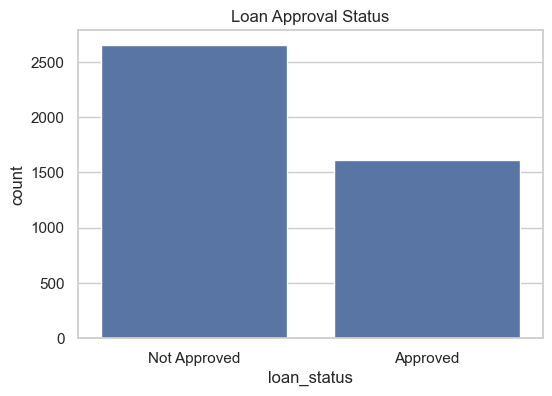

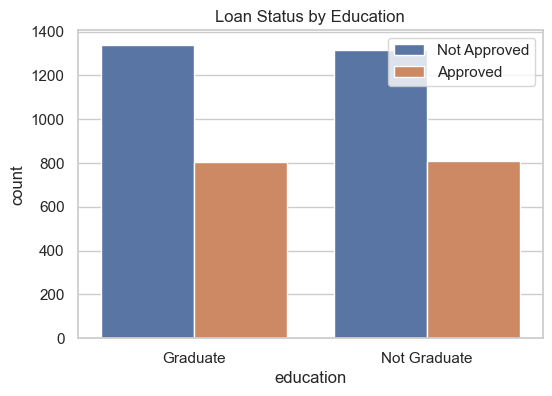

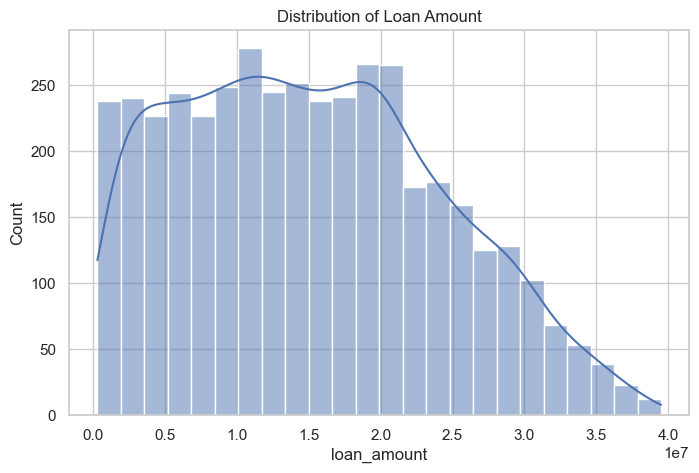

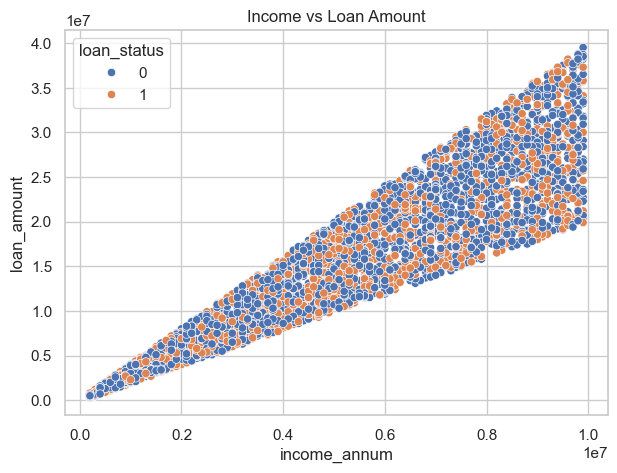

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Loan status count
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Status")
plt.xticks([0, 1], ['Not Approved', 'Approved'])
plt.show()

# 2. Loan Status vs Education
plt.figure(figsize=(6,4))
sns.countplot(x='education', hue='loan_status', data=df)
plt.title("Loan Status by Education")
plt.xticks([0, 1], ['Graduate', 'Not Graduate'])
plt.legend(['Not Approved', 'Approved'])
plt.show()

# 3. Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amount'], kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

# 4. Income vs Loan Amount
plt.figure(figsize=(7,5))
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.show()


# Model Building — Predict Loan Approval

#  Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Train and test sets created:")
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


✅ Train and test sets created:
Train size: (3415, 11), Test size: (854, 11)


# Train a Basic Classifier (Random Forest)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation
print("🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))


🎯 Accuracy: 0.9789227166276346

📊 Confusion Matrix:
 [[530   6]
 [ 12 306]]

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



# Compare with Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Evaluate
print("🔹 Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\n🔹 Classification Report:\n", classification_report(y_test, log_pred))


🔹 Logistic Regression Accuracy: 0.7962529274004684

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.85       536
           1       0.80      0.60      0.69       318

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854



# Feature Importance from Random Forest

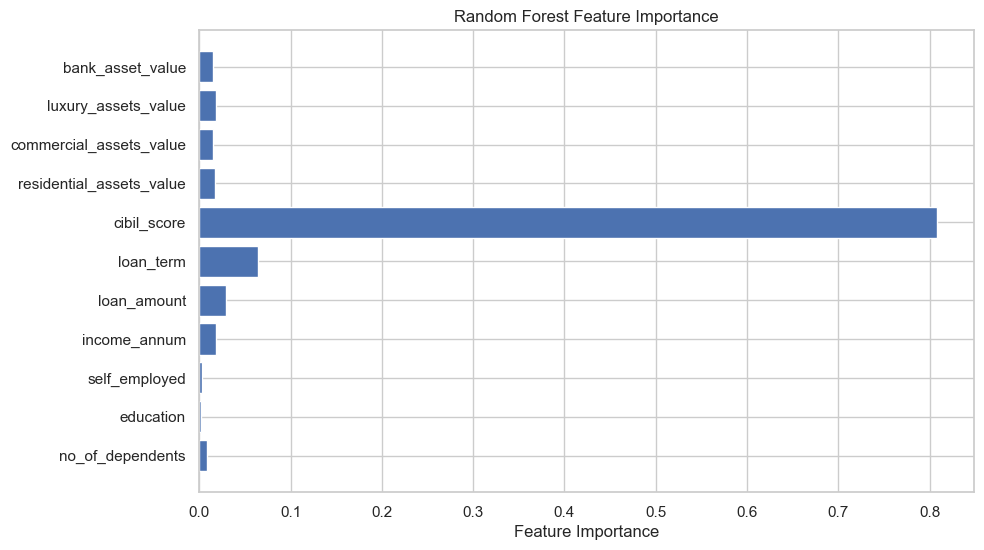

In [13]:
import matplotlib.pyplot as plt

# Get feature importance
importances = model.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()


# Hyperparameter Tuning with GridSearchCV (Random Forest)

# Apply GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create GridSearchCV object
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid,
                           cv=3,  # 3-fold cross-validation
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Best Accuracy on Training Set:", grid_search.best_score_)


# Evaluate the Best Model on Test Set

In [15]:
# Use the best model to predict
best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)

# Evaluate
print("🎯 Tuned Model Accuracy:", accuracy_score(y_test, y_best_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_best_pred))


🎯 Tuned Model Accuracy: 0.9789227166276346

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [16]:
import joblib

# Save the best model
joblib.dump(best_model, "loan_approval_model.pkl")
print("✅ Model saved as 'loan_approval_model.pkl'")


✅ Model saved as 'loan_approval_model.pkl'
